# Calculating Magnitudes for a user-provided SED #

This notebook provides an example of calculating the expected AB magnitude in each filter for a GRB (SED) with Rubin Observatory.

This was adapted from the 'Calculate Magnitude' notebook in [rubin_sim_notebooks](https://github.com/lsst/rubin_sim_notebooks).


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import some generally useful packages

import os
import numpy as np
import numpy
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

In [3]:
# Import the primary photometry classes from rubin_sim.photUtils
import rubin_sim.photUtils.Bandpass as Bandpass
import rubin_sim.photUtils.Sed as Sed

## Read the throughput curves ##

The throughput curves are currently downloaded as part of the `rs_download_data` script, and stored in `$RUBIN_SIM_DATA_DIR`. The default value for `$RUBIN_SIM_DATA_DIR` is `$HOME/rubin_sim_data`. 

In [4]:
# Find the throughputs directory 
fdir = '/home/bregeon/Rubin/FINK/rubin_sim/rubin_sim_data'
fdir = os.path.join(fdir, 'throughputs', 'baseline')
!ls $fdir

atmos_10.dat   filter_u.dat    hardware_y.dat  m3.dat		 total_y.dat
atmos_std.dat  filter_y.dat    hardware_z.dat  README.md	 total_z.dat
darksky.dat    filter_z.dat    lens1.dat       README_SOURCE.md  version_info
detector.dat   hardware_g.dat  lens2.dat       total_g.dat
filter_g.dat   hardware_i.dat  lens3.dat       total_i.dat
filter_i.dat   hardware_r.dat  m1.dat	       total_r.dat
filter_r.dat   hardware_u.dat  m2.dat	       total_u.dat


In [5]:
# Read the throughput curves
filterlist = ['u', 'g', 'r', 'i', 'z', 'y']

lsst = {}
for f in filterlist:
    lsst[f] = Bandpass()
    lsst[f].readThroughput(os.path.join(fdir, f'total_{f}.dat'))

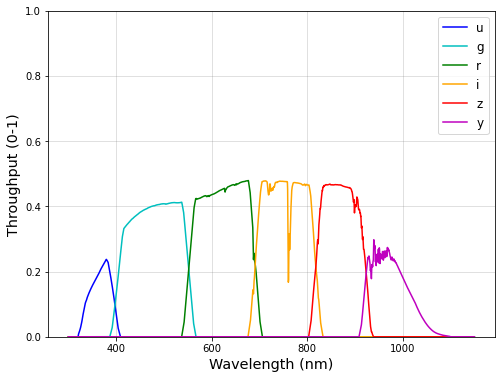

In [6]:
# Plot the curves .. see what we have. 
filtercolors = {'u':'b', 'g':'c', 'r':'g', 'i':'orange', 'z':'r', 'y':'m'}

plt.figure(figsize=(8,6))
for f in filterlist:
    plt.plot(lsst[f].wavelen, lsst[f].sb, color=filtercolors[f], label=f)
plt.xlabel("Wavelength (nm)", fontsize='x-large')
plt.ylabel("Throughput (0-1)", fontsize='x-large')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, color='gray')
plt.legend(loc='upper right', fancybox=True, fontsize='large')

## Read a GRB SED and compute magnitudes
Now read a GRB SED, created with `scripts/plot_grb_sed.py`, and compute magnitudes

In [23]:
grb_sed_file = '../scripts/my_grb_sed.txt'
grb_sed = Sed()
grb_sed.readSED_fnu(grb_sed_file)


Text(0, 0.5, '$\\lambda F_\\lambda$ (ergs/cm$^2$/s)')

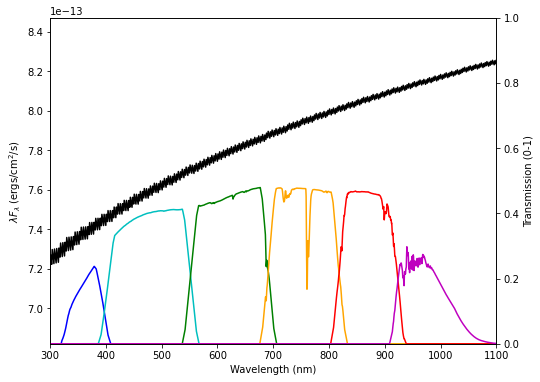

In [8]:
# Let's see what the SED and throughputs look like together
fig = plt.figure(figsize=(8,6))
ax1 = plt.subplot(1,1,1)
ax2 = ax1.twinx()
for f in filterlist:
    ax2.plot(lsst[f].wavelen, lsst[f].sb, color=filtercolors[f])
ax1.plot(grb_sed.wavelen, grb_sed.wavelen*grb_sed.flambda, color='k')
plt.xlim(300, 1100)
ax1.set_xlabel('Wavelength (nm)')
ax2.set_ylabel('Transmission (0-1)')
ax2.set_ylim(0, 1)
ax1.set_ylabel('$\lambda F_\lambda$ (ergs/cm$^2$/s)')

In [9]:
grb_sed.wavelen, grb_sed.flambda, grb_sed.fnu

(array([ 200.,  201.,  202., ..., 1297., 1298., 1299.]),
 array([3.44761327e-15, 3.48759821e-15, 3.45315301e-15, ...,
        6.46915230e-16, 6.45918826e-16, 6.44924723e-16]),
 array([4.60e-05, 4.70e-05, 4.70e-05, ..., 3.63e-04, 3.63e-04, 3.63e-04]))

In [10]:
grb_sed.calcMag(lsst['i'])

18.151071489037474

In [11]:
# Calculate expected AB magnitudes. 
grb_mags = {}
for f in filterlist:
    grb_mags[f] = grb_sed.calcMag(lsst[f])

# Make a dataframe just to get a nice output cell.
pd.DataFrame(grb_mags, index=['GRB']).T

,GRB
u,19.011843
g,18.697306
r,18.381084
i,18.151071
z,17.980282
y,17.844501


In [12]:
# check g - r
print(f'GRB color: g-r = {grb_mags["g"]-grb_mags["r"]:.2f}')

GRB color: g-r = 0.32


In [13]:
# try to add a redshift?
grb_sed.redshiftSED(0.5)

# Calculate expected AB magnitudes. 
grb_mags_z1 = {}
for f in filterlist:
    grb_mags_z1[f] = grb_sed.calcMag(lsst[f])

# Make a dataframe just to get a nice output cell.
pd.DataFrame(grb_mags_z1, index=['GRB']).T

,GRB
u,18.615608
g,18.301136
r,17.985072
i,17.754832
z,17.584039
y,17.448219


## Now build a GRB SED and feed it directly to rubin_sim

In [14]:
from orphans.grb_interface import make_grb_spectrum, dump_wl_Fnu_spectrum
wl_full_band, freq_full_band, t, Fnu_Jy = make_grb_spectrum()


In [15]:
new_grb_sed = Sed()
new_grb_sed.wavelen = numpy.array(wl_full_band)
new_grb_sed.fnu = numpy.array(Fnu_Jy)
# convert fnu to flambda
new_grb_sed.fnuToflambda()
new_grb_sed.wavelen, new_grb_sed.flambda, new_grb_sed.fnu

(array([ 200,  201,  202, ..., 1297, 1298, 1299]),
 array([3.47847401e-15, 3.46289487e-15, 3.44746230e-15, ...,
        6.46650742e-16, 6.46202354e-16, 6.45754621e-16]),
 array([4.64117614e-05, 4.66670898e-05, 4.69225453e-05, ...,
        3.62851589e-04, 3.63159339e-04, 3.63467113e-04]))

In [16]:
# Calculate expected AB magnitudes. 
new_grb_mags = {}
for f in filterlist:
    new_grb_mags[f] = new_grb_sed.calcMag(lsst[f])

# Make a dataframe just to get a nice output cell.
pd.DataFrame(new_grb_mags, index=['New GRB']).T

,New GRB
u,19.011676
g,18.697288
r,18.381104
i,18.151043
z,17.980290
y,17.844464
